In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.files import get_latest_file
from pathlib import Path
import missingno as msno
from statsmodels.tsa.stattools import adfuller
from src.utils.clean_data import remove_cols
from src.data.data_utils import split_sequences
import keras
import tensorflow as tf

In [15]:
@keras.saving.register_keras_serializable()
class BlockDiagonal(keras.layers.Layer):

    """
    Block diagonal layer that takes an entire feature vector of dimension 
    input_dim and splits it into num_heads each with dimension 
    head_dim = input_dim // num_heads. Then, each head performs a linear
    projection along the head_dim outputing a tensor of shape 
    (batch, num_heads, head_dim) 
    """

    def __init__(
            self, 
            num_heads,
            units,
            kernel_initializer='glorot_uniform',
            kernel_regularizer=None, 
            use_bias=False,
            **kwargs
        ):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.units = units
        self.kernel_initializer = kernel_initializer
        self.kernel_regularizer = kernel_regularizer
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.head_dim = input_dim // self.num_heads

        self.W = self.add_weight( 
            shape=(self.num_heads, self.units, self.head_dim),
            initializer=self.kernel_initializer,
            regularizer=self.kernel_regularizer,
            name='weights'
        )

        if self.use_bias:
            self.b = self.add_weight(
                shape=(self.num_heads, self.units)
            )
        else:
            self.b = None

    def call(self, x):
        # x comes in the shape (batch, input_dim) but we want (batch, num_heads, head_dim)
        batch = tf.keras.ops.shape(x)[0]

        # Partition the input
        x =  tf.keras.ops.reshape(
            x, 
            (batch, self.num_heads, self.head_dim)
        )
        
        # Einstein sum as an efficient alternative to Block diagonal matrix
        #  multiplication. Equivalent to multiplying each weight matrix by the
        #  corresponding input subset (along dimension j)
        # Doing this for the whole batch results in shape 
        # (batch, num_heads, units). Bias broadcasts across batch
        y = tf.keras.ops.einsum("nuh,bnh->bnu", self.W, x)
        if self.use_bias:
            y = y + self.b

        return y
    
    def get_config(self):
        config = super().get_config()
        config.update(
            {
                'num_heads': self.num_heads,
                'units': self.units,
                'use_bias': self.use_bias,
                'kernel_initializer': self.kernel_initializer,
                'kernel_regularizer': self.kernel_regularizer
            }
        )
        return config

@keras.saving.register_keras_serializable()   
class MultiHeadSLSTMCell(keras.layers.Layer):
    def __init__(
            self, 
            units, 
            num_heads,
            kernel_initializer="glorot_uniform",
            recurrent_initializer='orthogonal', 
            recurrent_regularizer=None,
            kernel_regularizer=None,
            **kwargs
        ):
        super().__init__(**kwargs)
        self.units = units
        self.num_heads = num_heads
        self.head_size = self.units // self.num_heads
        self.state_size = (self.units, self.units, self.units, self.units)
        self.kernel_initializer = kernel_initializer
        self.recurrent_initializer = recurrent_initializer
        self.kernel_regularizer = kernel_regularizer
        self.recurrent_regularizer = recurrent_regularizer
        
        self.input_block = BlockDiagonal(
            num_heads, 
            4 * self.head_size, 
            kernel_initializer=kernel_initializer,
            kernel_regularizer=kernel_regularizer,
            use_bias=False
        )
        self.recurrent_block = BlockDiagonal(
            num_heads, 
            4 * self.head_size,
            kernel_initializer=recurrent_initializer,
            kernel_regularizer=recurrent_regularizer,
            use_bias=False
        )


    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.input_block.build(input_shape) # Build blocks for model.summary()

        recurrent_shape = (None, self.units)
        self.recurrent_block.build(recurrent_shape)

        # Initialize bias. Weights are initialized within BlockDiagonal
        self.biases = self.add_weight(
            shape=(self.num_heads, 4 * self.head_size),
            initializer='zeros',
            name='biases'
        )

        # sets self.built=True so build is not called on every forward pass
        super().build(input_shape) 
    
    def call(self, inputs, states):
        
        # Each state is shape (units)
        h_prev, c_prev, n_prev, m_prev = states 

        # preactivation. returns (batch, num_heads, 4 * head_size)
        z = (
            self.input_block(inputs) + 
            self.recurrent_block(h_prev) + 
            self.biases
        )

        # Reshape each state to (num_heads, head_size)
        h_prev =  tf.keras.ops.reshape(
            h_prev, 
            (-1, self.num_heads, self.head_size),
        )
        c_prev =  tf.keras.ops.reshape(
            c_prev, 
            (-1, self.num_heads, self.head_size),
        )
        n_prev =  tf.keras.ops.reshape(
            n_prev, 
            (-1, self.num_heads, self.head_size)
        )
        m_prev =  tf.keras.ops.reshape(
            m_prev, 
            (-1, self.num_heads, self.head_size)
        )

        # Splits pre-activation into one tensor of shape
        #  (batch, num_heads, head_size) for each gate
        i_candidate, f_candidate, z_candidate, o_candidate = tf.split(
            z, 
            num_or_size_splits=4, 
            axis=2
        )

        # Main sLSTM math
        logfplusm =  tf.keras.ops.log_sigmoid(f_candidate) + m_prev

        m = tf.keras.ops.cond(
            tf.keras.ops.all(
                tf.keras.ops.equal(n_prev, 0.0)
            ),
            lambda: i_candidate,
            lambda: tf.keras.ops.maximum(i_candidate, logfplusm),
        )
        
        # usual output gate and cell state candidate
        o =  tf.keras.ops.sigmoid(o_candidate)
        z =  tf.keras.ops.tanh(z_candidate)

        # Stabilized input and foreget gates
        i = tf.keras.ops.minimum( 
            tf.keras.ops.exp(i_candidate - m),  
            tf.keras.ops.ones_like(i_candidate)
        )
        f =  tf.keras.ops.minimum( 
            tf.keras.ops.exp(logfplusm - m),  
            tf.keras.ops.ones_like(i_candidate)
        )
        
        c = f * c_prev + i * z
        n = f * n_prev + i
        h = o * c / n

        # Reshape states back to original shape (batch, units)
        h =  tf.keras.ops.reshape(
            h, 
            (-1, self.num_heads*self.head_size) 
        )
        c =  tf.keras.ops.reshape(
            c, 
            (-1, self.num_heads*self.head_size)
        )
        n =  tf.keras.ops.reshape(
            n, 
            (-1, self.num_heads*self.head_size) 
        )
        m =  tf.keras.ops.reshape(
            m, 
            (-1, self.num_heads*self.head_size)
        )
        
        return h, [h, c, n, m]
    
    def get_config(self):
        config = super().get_config()
        config.update(
            {
                'units': self.units,
                'num_heads': self.num_heads,
                'kernel_initializer': self.kernel_initializer,
                'recurrent_initializer': self.recurrent_initializer,
                'kernel_regularizer': self.kernel_regularizer,
                'recurrent_regularizer': self.recurrent_regularizer,
            }
        )
        return config

@keras.saving.register_keras_serializable()
class sLSTMBlock(keras.layers.Layer):

    def __init__(
        self,
        units,
        num_heads,
        return_sequences=False,
        kernel_regularizer=None,
        recurrent_regularizer=None,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.units = units
        self.num_heads = num_heads
        self.return_sequnces = return_sequences
        self.kernel_regularizer = kernel_regularizer
        self.recurrent_regularizer = recurrent_regularizer

        self.input_proj = keras.layers.Dense(
            units=units,
            name=f'{self.name}_input_proj'
        )

        self.ln1 = keras.layers.LayerNormalization(name=f'{self.name}_ln1')
        self.slstm = keras.layers.RNN(
            MultiHeadSLSTMCell(
                units=units,
                num_heads=num_heads,
                kernel_regularizer=kernel_regularizer,
                recurrent_regularizer=recurrent_regularizer
            ),
            return_sequences=return_sequences,
            name=f'{self.name}_slstm'
        )
        self.gn = keras.layers.GroupNormalization(
            groups=num_heads,
            name=f'{self.name}_gn'
        )
        self.add = keras.layers.Add(name=f'{self.name}_add')

        self.ln2 = keras.layers.LayerNormalization(name=f'{self.name}_ln2')

        self.up_proj_left = keras.layers.Dense(
            units=int(4*units/3), 
            kernel_regularizer=kernel_regularizer,
            name=f'{self.name}_up_proj_left'
        )
        self.up_proj_right = keras.layers.Dense(
            units=int(4*units/3),
            kernel_regularizer=kernel_regularizer,
            name=f'{self.name}_up_proj_right'
        )

        self.gelu = keras.layers.Activation('gelu', name=f'{self.name}_gelu')
        self.mult = keras.layers.Multiply(name=f'{self.name}_mult')

        self.down_proj = keras.layers.Dense(
            units=units,
            kernel_regularizer=kernel_regularizer,
            name=f'{self.name}_down_proj'
        )

    def __call__(self, inputs):

        x_in = self.input_proj(inputs[:,-1,:])

        print(inputs.shape)
        x = self.ln1(inputs)
        print(x.shape)
        x = self.slstm(x)
        print(x.shape)
        x = self.gn(x)
        print(x.shape)
        x = self.add([x,x_in])

        if self.return_sequnces:
            print(x.shape)
            return x
        else:
            y = self.ln2(x)
            y_l = self.up_proj_left(y)
            y_r = self.up_proj_right(y)
            y_r = self.gelu(y_r)
            y = self.mult([y_l,y_r])
            y = self.down_proj(y)
            y = self.add([y,x])

            return y
    
    def get_config(self):
        config = super().get_config()

        config.update(
            {
                'units': self.units,
                'num_heads': self.num_heads,
                'return_sequences': self.return_sequnces,
                'kernel_regularizer': self.kernel_regularizer,
                'recurrent_regularizer': self.recurrent_regularizer
            }
        )

        return config

def generate_data(n_samples, num_heads=2,n_features=4):

    assert n_features % num_heads == 0
    np.random.seed(1)
    head_dim = n_features // num_heads
    X = np.random.randn(n_samples, n_features).reshape(n_samples, num_heads, head_dim)
    W_true = np.ones((num_heads, head_dim))
    
    y = np.einsum('nhi,hi->n', X, W_true)

    return X, y


### Test block diagonal layer 

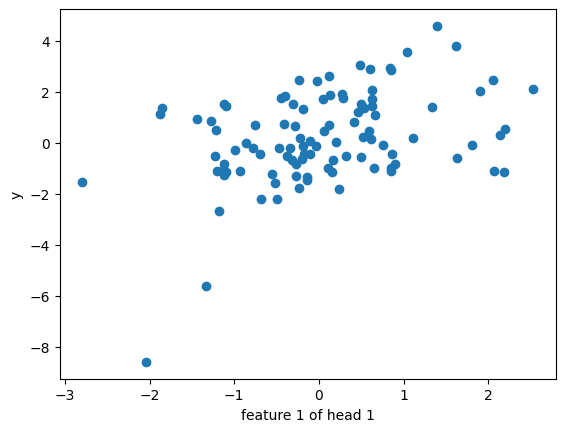

In [65]:
import matplotlib.pyplot as plt

X, y = generate_data(n_samples=100)

plt.scatter(X[:,0, 0], y)
plt.xlabel('feature 1 of head 1')
plt.ylabel('y')
plt.show()

In [66]:
# Make a simple neural network
model = keras.models.Sequential()
model.add(BlockDiagonal(num_heads=2, units=1))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')

model.fit(X.reshape(X.shape[0], -1), y, epochs=100, batch_size=4)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3747  
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7058 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1751 
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0325 
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7401e-04 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0508e-05 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6364e-05 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.3558e-06 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.3628e-06 
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2528e-06 
Epoch 13/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4911e-07 
Epoch 14/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6431e-07 
Epoch 15/100
25/25 ━━━━━

In [67]:
y_pred = model.predict(X.reshape(X.shape[0], -1))

print(f"MSE: {np.sum(y_pred - y)**2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
MSE: 4.795811098520755e-09


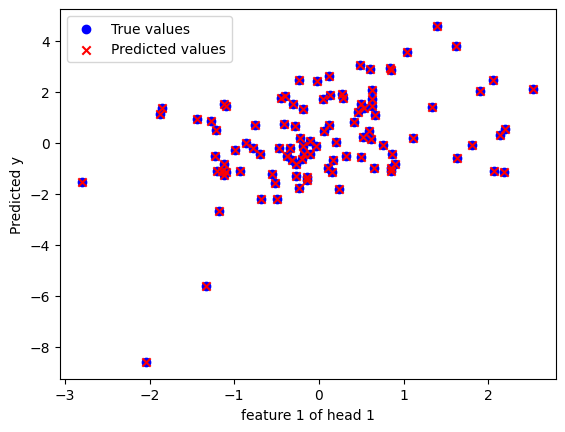

In [68]:
plt.scatter(X[:,0, 0], y, c='blue', label='True values')
plt.scatter(X[:,0, 0], y_pred, c='red', marker='x', label='Predicted values')
plt.xlabel('feature 1 of head 1')
plt.ylabel('Predicted y')
plt.legend()
plt.show()

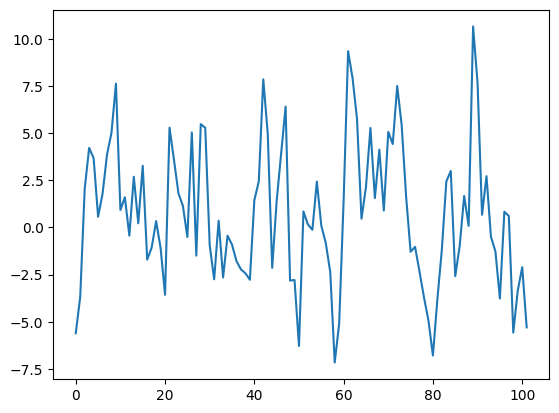

In [5]:
timesteps = 3
features = 20
n_samples = 100 + (timesteps-1) # Buffer for resulting NaNs from lags

def generate_timeseries(n_samples, n_timesteps, n_features, seed=1):

    np.random.seed(seed)

    X_0 = np.random.randn(n_samples,n_features)
    X = X_0.copy()
    for i in range(1, n_timesteps):
        X_i = np.roll(X_0, shift=i, axis=0)
        X = np.column_stack([X,X_i])

    true_W = np.linspace(0.9, 0.01, features*timesteps).reshape(-1,1)
    y = X @ true_W  

    return X_0, y

X_0, y = generate_timeseries(
    n_samples=n_samples, 
    n_timesteps=timesteps,
    n_features=features
)
time = np.arange(X_0.shape[0])
plt.plot(time, y.flatten())
plt.show()

data = np.column_stack([X_0, y])
X_rnn, y_rnn = split_sequences(data, n_timesteps=3, n_targets=1)

In [ ]:
model = keras.models.Sequential()
model.add(
    keras.layers.RNN(
        MultiHeadSLSTMCell(
            units=8,
            num_heads=2
        ),
        return_sequences=False
    )
)
model.add(keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')

In [73]:
2*16*10 + 2*16*4 + 2*16

480

In [ ]:
# 2 heads
# Each head has one preactivation with input matrix W and recurrent matrix R
# and bias b
# W is shape (num_heads, num_gates*(units//num_heads), features//num_heads)
#   in this case (2,16,10)
# R is shape (num_heads, num_gates*(units//num_heads), units//num_heads)
#   in this case (2,16,4)
# b is shape (num_heads, num_gates*(units//num_heads))
#   in this case (2, 16)
# Total parameters = 2*16*10 + 2*16*4 + 2*16 = 480 
model.build(input_shape=(None,None,20))
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_6 (RNN)                     │ (None, 8)              │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489 (1.91 KB)

 Trainable params: 489 (1.91 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
keras.utils.plot_model(model, 'model.png')

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [76]:
model.fit(X_rnn, y_rnn, epochs=100, batch_size=8)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.8768
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.1108
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.4696 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.8388
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.1499
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.4265 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.6028 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.6733  
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.7275 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8514 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9359 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0837 
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3741 
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7467 
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


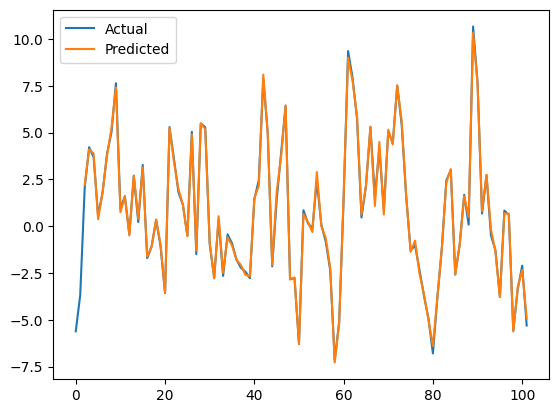

In [77]:
predictions = model.predict(X_rnn)

plt.plot(time, y, label='Actual')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted')
plt.legend()
plt.show()

Epoch 1/100
(None, 3, 20)
(None, 3, 20)
(None, 3, 8)
(None, 3, 8)
(None, 3, 8)
(None, 3, 8)
(None, 3, 8)
(None, 8)
(None, 8)
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.0873
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.4633 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.9261
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.9151
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5324
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1040
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1155
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4590
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3103
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0799
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3650
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8020
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6603
Epoch 14/100
13/13 ━━━━

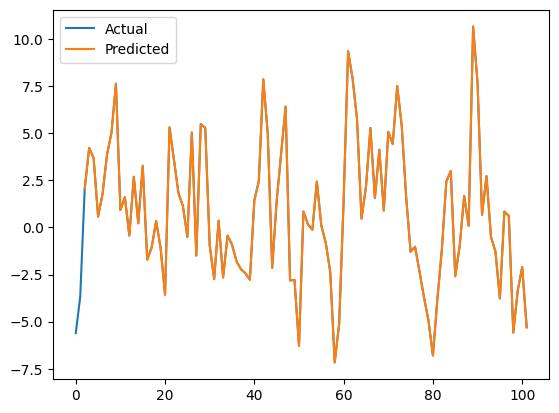

In [16]:
model = keras.models.Sequential()
model.add(
    sLSTMBlock(
        units=8,
        num_heads=2,
        kernel_regularizer=keras.regularizers.L2(0.001),
        recurrent_regularizer=keras.regularizers.L2(0.001),
        return_sequences=True
    )
)
model.add(
    sLSTMBlock(
        units=8,
        num_heads=2,
        kernel_regularizer=keras.regularizers.L2(0.001),
        recurrent_regularizer=keras.regularizers.L2(0.001)
    )
)
model.add(keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')

model.fit(X_rnn, y_rnn, epochs=100, batch_size=8)
predictions = model.predict(X_rnn)

plt.plot(time, y, label='Actual')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


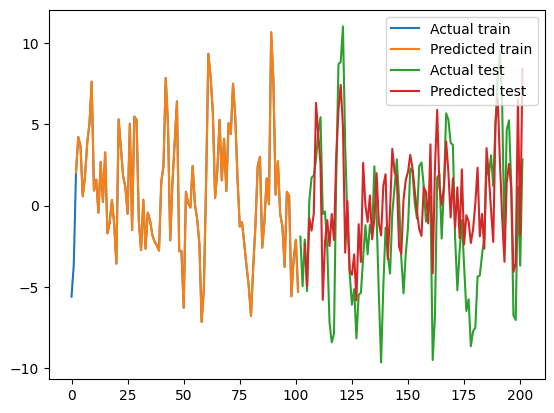

In [17]:
# Test data
X_test, y_test = generate_timeseries(100, 3, 20, seed=2)

X_test_rnn, y_test_rnn = split_sequences(
    data=np.column_stack([X_test, y_test]),
    n_timesteps=3,
    n_targets=1
)

test_pred = model.predict(X_test_rnn)

test_time = np.arange(X_0.shape[0], X_0.shape[0] + X_test.shape[0])
plt.plot(time, y, label='Actual train')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted train')
plt.plot(test_time, y_test, label='Actual test')
plt.plot(test_time[-test_pred[:,0].shape[0]:], test_pred[:,0], label='Predicted test')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step


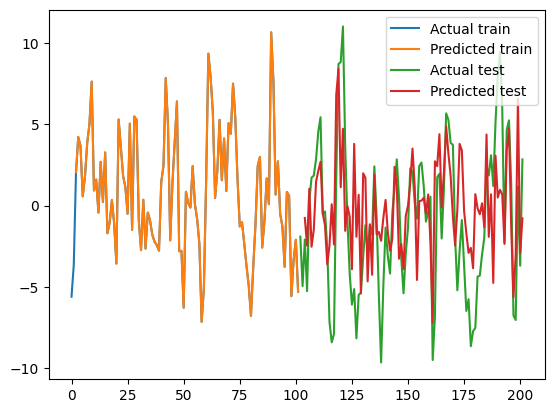

In [89]:
# Test model saving
model.save('model.keras')

# test model loading
model = keras.models.load_model('model.keras')

test_pred = model.predict(X_test_rnn)

test_time = np.arange(X_0.shape[0], X_0.shape[0] + X_test.shape[0])
plt.plot(time, y, label='Actual train')
plt.plot(time[-predictions.shape[0]:], predictions[:,0], label='Predicted train')
plt.plot(test_time, y_test, label='Actual test')
plt.plot(test_time[-test_pred[:,0].shape[0]:], test_pred[:,0], label='Predicted test')
plt.legend()
plt.show()